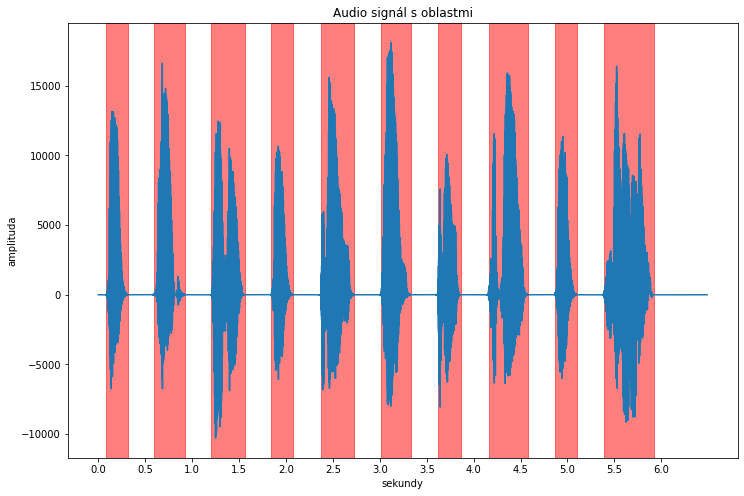

the ('the', 317.98) ('no', 1547.27) ('to', 1783.22)
work ('work', 343.29) ('make', 1425.27) ('no', 1465.67)
easy ('easy', 555.51) ('idea', 1422.65) ('make', 1581.69)
the ('the', 423.29) ('no', 1415.38) ('long', 1765.01)
time ('time', 404.74) ('to', 1239.14) ('fail', 1516.94)
long ('no', 1073.59) ('long', 1182.24) ('work', 1302.03)
to ('to', 912.09) ('the', 1348.64) ('time', 1405.0)
prepare ('idea', 758.74) ('prepare', 1007.83) ('probable', 1186.11)
the ('the', 402.94) ('no', 1247.82) ('long', 1782.51)
solution ('solution', 1706.23) ('for', 2439.3) ('disaster', 2532.87)
Správně: 8/10 (80.0%)
('time', 0, 8828, 0.044313821144875476)
('time', 13242, 22070, 0.02897115308956999)
('time', 26484, 35312, 0.027164751217627625)
('time', 28691, 37519, 0.03780560675194311)
('time', 39726, 48554, 0.034714321074627796)
('time', 50761, 59589, 0.030538749430988776)
('time', 52968, 61796, 0.011380837656984277)
('time', 66210, 75038, 0.02000261601657516)
('time', 79452, 88280, 0.024068689507941055)
('tim

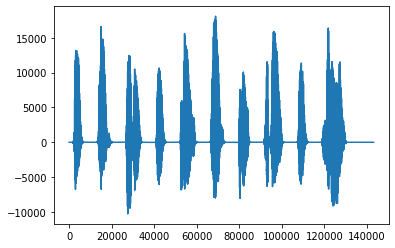

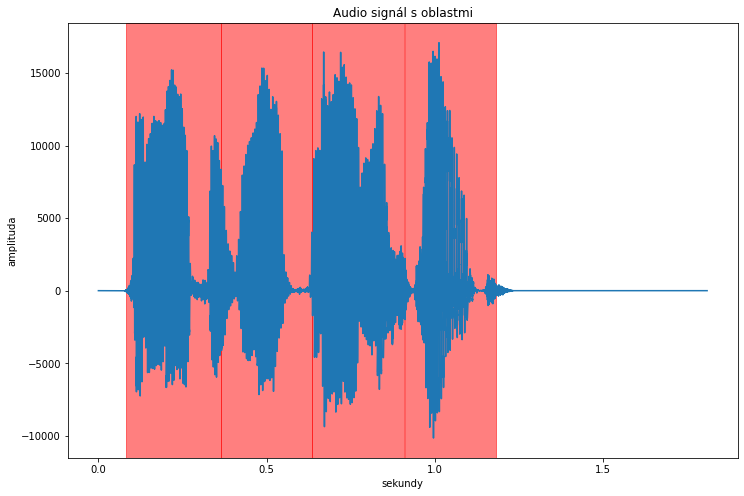

('long', 1191.14) ('idea', 1202.73) ('no', 1391.45)
('no', 1038.37) ('work', 1322.38) ('long', 1355.12)
('work', 2107.49) ('no', 2137.56) ('idea', 2415.63)
('to', 1817.72) ('time', 1913.95) ('the', 2002.57)


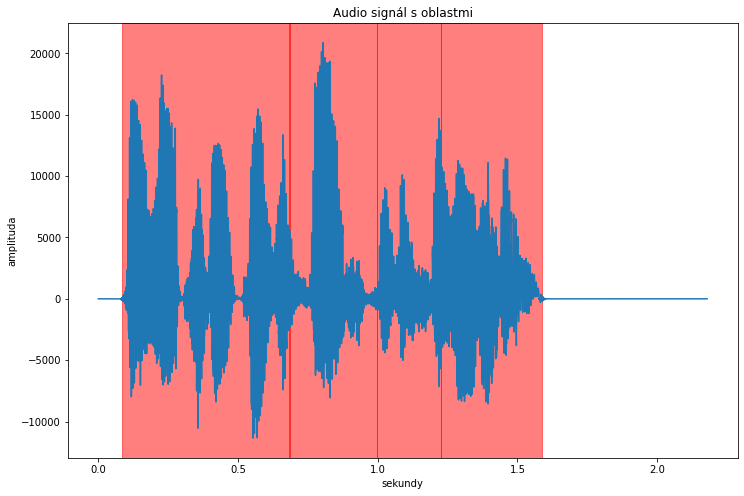

('prepare', 2608.35) ('disaster', 2614.93) ('idea', 2664.98)
('is', 1650.83) ('work', 1758.96) ('make', 2105.83)
('easy', 1880.77) ('the', 1969.88) ('idea', 2211.37)
('easy', 1365.55) ('idea', 1398.37) ('long', 1808.53)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pyttsx3
import os
import scipy.io.wavfile
import scipy.signal
import scipy.spatial.distance
import librosa
import librosa.display
import copy

SLOVA = [
    "time", "prepare", "solution", "make", "mistake", "no", "the", "probable", "long", "lecture",
    "method", "disaster", "fail", "work", "advice", "idea", "succeed", "easy", "is", "for", "give",
    "to"
]

SLOVA_ADRESAR = "slova/"
SOLUTION = ["the", "work", "easy", "the", "time", "long", "to", "prepare", "the", "solution"]


### Generování WAV souborů slov

if not os.path.exists(SLOVA_ADRESAR):
    os.mkdir(SLOVA_ADRESAR)

engine = pyttsx3.init()
for slovo in SLOVA:
    # přeskočit existující soubory
    if os.path.exists(os.path.join(SLOVA_ADRESAR, "%s.wav" % slovo)):
        continue
    engine.save_to_file(slovo, os.path.join(SLOVA_ADRESAR, "%s.wav" % slovo))
engine.runAndWait()

### Pomocné funkce

def orezat_signal(s1, orezovy_prah=10):
    s1[(-orezovy_prah < s1) & (s1 < orezovy_prah)] = 0

    fhalf = s1[:s1.size // 2]
    zacatek_orezany = fhalf[fhalf == 0].size
    shalf = s1[s1.size // 2:]
    konec_orezany = shalf[shalf == 0].size

    ts1 = np.trim_zeros(s1)
    return ts1, zacatek_orezany, konec_orezany

def orezat_a_zarovnat_par(s1, s2, orezovy_prah=10):
    ts1, _, _ = orezat_signal(s1)
    ts2, _, _ = orezat_signal(s2)
    velikost_max = max(ts1.size, ts2.size)
    velikost_pad = (velikost_max // 1000 + 1) * 1000
    ps1 = np.pad(ts1, (0, velikost_pad - ts1.size))
    ps2 = np.pad(ts2, (0, velikost_pad - ts2.size))

    return ps1, ps2

def nacist_soubor(filename):
    fs, s = scipy.io.wavfile.read(filename)
    s, _, _ = orezat_signal(s)
    return fs, s.astype(np.float64)

def nacist_slovo(slovo):
    filename = os.path.join(SLOVA_ADRESAR, "%s.wav" % slovo)
    return nacist_soubor(filename)

def zapsat_wav(data, filename, rate=22050):
    scipy.io.wavfile.write(filename, rate, data)

def rozdelit_data(data, velikost_okna=1000, prah=1600):
    data = copy.deepcopy(data)

    base = 0
    je_hlas = False
    n_prazdnych = 0

    msize = data.size
    psize = (msize // velikost_okna + 1) * velikost_okna
    data = np.pad(data, (0, psize - data.size))

    dily = []
    oblasti = []

    for i, okno in enumerate(np.split(data, data.size / velikost_okna)):
        _max = np.max(np.abs(okno))
        if n_prazdnych > 1 and je_hlas:
            dil = data[base:(i + 1) * velikost_okna]
            dil, zacatek_orezany, konec_orezany = orezat_signal(dil)
            dily.append(dil)

            oblasti.append((base + zacatek_orezany, base + zacatek_orezany + dil.size))

            base = (i + 1) * velikost_okna
            je_hlas = False
            n_prazdnych = 0
        elif _max >= prah and not je_hlas:
            je_hlas = True
        elif _max < prah and je_hlas:
            n_prazdnych += 1

    if not dily:
        return [data], None
    return dily, oblasti

### Nahrát data

data = np.loadtxt("Signal1.txt")
#data = data[:data.size - data.size%1000]

awords = []
for slovo in SLOVA:
    sr, X = nacist_slovo(slovo)
    awords.append((slovo, sr, X))

### Rozdělit data
dily, oblasti = rozdelit_data(data)

ymin = np.min(data)
ymax = np.max(data)

plt.figure(figsize=(12, 8))

plt.plot(data)

for i, (start, end) in enumerate(oblasti):
    color = "red"
    plt.axvspan(start, end, color=color, alpha=0.5)

ticks = np.arange(0, len(data), 22050/2)
plt.xticks(ticks, np.round(ticks/22050, 2))

plt.xlabel("sekundy")
plt.ylabel("amplituda")
plt.title("Audio signál s oblastmi")

plt.show()

spravne = 0
for odpoved, Y in zip(SOLUTION, dily):
    podobnosti = []
    for (slovo, sr, X) in awords:
        pX, pY = orezat_a_zarovnat_par(X, Y)

        sX = librosa.feature.melspectrogram(y=pX, sr=sr, n_fft=2048)
        mfccsX = librosa.feature.mfcc(S=librosa.power_to_db(sX))
        sY = librosa.feature.melspectrogram(y=pY, sr=sr, n_fft=2048)
        mfccsY = librosa.feature.mfcc(S=librosa.power_to_db(sY))
        (dist_mfccs, _, _) = scipy.spatial.distance.directed_hausdorff(mfccsX, mfccsY)

        (dist_sc, _, _) = scipy.spatial.distance.directed_hausdorff(
            librosa.feature.spectral_centroid(y=pX, n_fft=2048),
            librosa.feature.spectral_centroid(y=pY, n_fft=2048)
        )

        similarity = dist_mfccs + dist_sc * 0.25

        podobnosti.append((slovo, similarity))

    hadani = sorted(podobnosti, key=lambda x: x[1])[:3]
    hadani = [(x[0], np.round(x[1], 2)) for x in hadani]
    print(odpoved, *hadani)
    if odpoved == hadani[0][0]:
        spravne += 1

procento_spravnych = spravne / len(dily) * 100
print("Správně: %s/%s (%s%%)" % (spravne, len(dily), procento_spravnych))

#dil = data[10000:22000]
dil = data
pomer_okna = 1/4
plt.plot(dil)

nejlepsi = None
min_vzdalenost = np.inf
prah = 0.045

detekovane = []

for (slovo, sr, X) in awords:

    base = 0
    velikost_okna = int(X.size * pomer_okna)

    while dil[base:].size >= X.size:
        end = base + X.size
        Y = dil[base:end]

        sX = librosa.feature.melspectrogram(y=X, sr=sr, n_fft=2048)
        mfccsX = librosa.feature.mfcc(S=librosa.power_to_db(sX))
        sY = librosa.feature.melspectrogram(y=Y, sr=sr, n_fft=2048)
        mfccsY = librosa.feature.mfcc(S=librosa.power_to_db(sY))
        dist = scipy.spatial.distance.cosine(mfccsX.flatten(), mfccsY.flatten())

        if dist < prah:
            detekovane.append((slovo, base, end, dist))

        base += velikost_okna

for t in detekovane:
    print(t)

data = np.loadtxt("Signal2.txt")
dily, oblasti = rozdelit_data(data, prah=15000)

len(oblasti)

ymin = np.min(data)
ymax = np.max(data)

plt.figure(figsize=(12, 8))

plt.plot(data)

for i, (start, end) in enumerate(oblasti):
    color = "red"
    plt.axvspan(start, end, color=color, alpha=0.5)

ticks = np.arange(0, len(data), 22050/2)
plt.xticks(ticks, np.round(ticks/22050, 2))

plt.xlabel("sekundy")
plt.ylabel("amplituda")
plt.title("Audio signál s oblastmi")

plt.show()

for Y in dily:
    podobnosti = []
    for (slovo, sr, X) in awords:
        pX, pY = orezat_a_zarovnat_par(X, Y)

        sX = librosa.feature.melspectrogram(y=pX, sr=sr, n_fft=2048)
        mfccsX = librosa.feature.mfcc(S=librosa.power_to_db(sX))
        sY = librosa.feature.melspectrogram(y=pY, sr=sr, n_fft=2048)
        mfccsY = librosa.feature.mfcc(S=librosa.power_to_db(sY))
        (dist_mfccs, _, _) = scipy.spatial.distance.directed_hausdorff(mfccsX, mfccsY)

        (dist_sc, _, _) = scipy.spatial.distance.directed_hausdorff(
            librosa.feature.spectral_centroid(y=pX, n_fft=2048),
            librosa.feature.spectral_centroid(y=pY, n_fft=2048)
        )

        similarity = dist_mfccs + dist_sc * 0.25

        podobnosti.append((slovo, similarity))

    hadani = sorted(podobnosti, key=lambda x: x[1])[:3]
    hadani = [(x[0], np.round(x[1], 2)) for x in hadani]
    print(*hadani)

data = np.loadtxt("Signal3.txt")
dily, oblasti = rozdelit_data(data, prah=10000)

len(oblasti)

ymin = np.min(data)
ymax = np.max(data)

plt.figure(figsize=(12, 8))

plt.plot(data)

for i, (start, end) in enumerate(oblasti):
    color = "red"
    plt.axvspan(start, end, color=color, alpha=0.5)

ticks = np.arange(0, len(data), 22050/2)
plt.xticks(ticks, np.round(ticks/22050, 2))

plt.xlabel("sekundy")
plt.ylabel("amplituda")
plt.title("Audio signál s oblastmi")

plt.show()

for Y in dily:
    podobnosti = []
    for (slovo, sr, X) in awords:
        pX, pY = orezat_a_zarovnat_par(X, Y)

        sX = librosa.feature.melspectrogram(y=pX, sr=sr, n_fft=2048)
        mfccsX = librosa.feature.mfcc(S=librosa.power_to_db(sX))
        sY = librosa.feature.melspectrogram(y=pY, sr=sr, n_fft=2048)
        mfccsY = librosa.feature.mfcc(S=librosa.power_to_db(sY))
        (dist_mfccs, _, _) = scipy.spatial.distance.directed_hausdorff(mfccsX, mfccsY)

        (dist_sc, _, _) = scipy.spatial.distance.directed_hausdorff(
            librosa.feature.spectral_centroid(y=pX, n_fft=2048),
            librosa.feature.spectral_centroid(y=pY, n_fft=2048)
        )

        similarity = dist_mfccs + dist_sc * 0.25

        podobnosti.append((slovo, similarity))

    hadani = sorted(podobnosti, key=lambda x: x[1])[:3]
    hadani = [(x[0], np.round(x[1], 2)) for x in hadani]
    print(*hadani)
